# Key changes over the model from the paper:
- Model capcity smaller (latent dims, GRU dims)
- Reconstruction loss
    - Token-level cross entropy on logits with PAD ignored
    - Rep does BCE on ont hot probabilities + KL
- KL anealling
- Free bits

- reduced complexity - lower dimensions overall and smaller convolution filter dims

In [2]:
import deepchem as dc

from rdkit import Chem

import numpy as np

import matplotlib.pyplot as plt

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary


No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/Users/iamthomaspruyn/Documents/PhD/Projects/AI-for-Toxicology/AI-for-Toxicology/.venv/lib/python3.11/site-packages/deepchem/models/torch_models/__init_

## Import the dataset from deepchem and prepare cannonicallized SMILES

In [3]:
# Force re-download / re-featurize and save cache to a stable folder
tasks, datasets, transformers = dc.molnet.load_tox21(
    featurizer="Raw",
    reload=True,
    data_dir="data",            # where raw data is stored
    save_dir="data/tox21-cache" # where featurized/cache files are written
)
train_dataset, valid_dataset, test_dataset = datasets

In [72]:
# We only need the SMILES strings
train_smiles = train_dataset.X
valid_smiles = valid_dataset.X
test_smiles  = test_dataset.X

# Convert the RDKit molecules to cannonicallized SMILES strings
train_smiles = [Chem.MolToSmiles(mol) for mol in train_dataset.X]
valid_smiles = [Chem.MolToSmiles(mol) for mol in valid_dataset.X]
test_smiles  = [Chem.MolToSmiles(mol) for mol in test_dataset.X]

print(train_smiles[:5])

['CC(O)(P(=O)(O)O)P(=O)(O)O', 'CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C', 'OC[C@@H](O)[C@H](O)[C@@H](O)CO', 'CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2]', 'CC(C)COC(=O)C(C)C']


### Filter out any strings above sequence length
We will use a sequence length of 120, just like the paper did. Even though we will have to remove some datapoints, this will make training much faster and a sequence length of 120 will cover over 90% of our datapoints


train: n=6258
  min=2  mean=31.3  median=25.0  max=277
  p 50=25
  p 75=37
  p 90=57
  p 95=73
  p 98=98
  p 99=130
  p100=277

valid: n=782
  min=9  mean=53.2  median=43.0  max=342
  p 50=43
  p 75=62
  p 90=88
  p 95=117
  p 98=174
  p 99=205
  p100=342

test: n=783
  min=5  mean=52.8  median=43.0  max=332
  p 50=43
  p 75=59
  p 90=90
  p 95=121
  p 98=196
  p 99=237
  p100=332


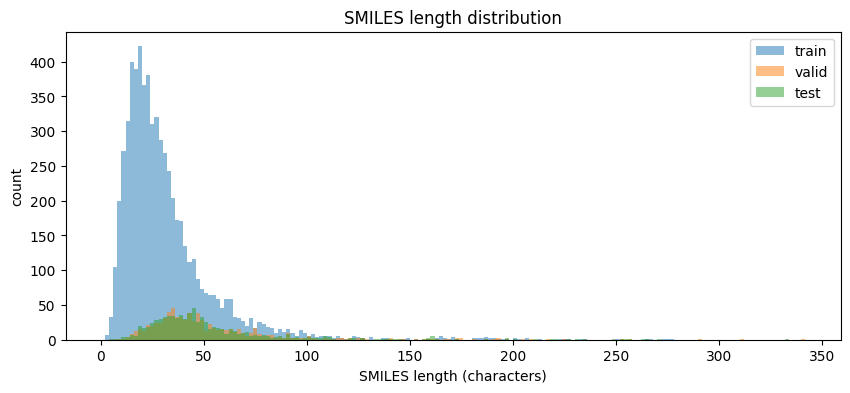

In [73]:
def summarize_lengths(name, smiles_list, percentiles=(50, 75, 90, 95, 98, 99, 100)):
    lens = np.array([len(s) for s in smiles_list], dtype=int)
    print(f"\n{name}: n={len(lens)}")
    print(f"  min={lens.min()}  mean={lens.mean():.1f}  median={np.median(lens):.1f}  max={lens.max()}")
    for p in percentiles:
        print(f"  p{p:>3}={np.percentile(lens, p):.0f}")
    return lens

train_lens = summarize_lengths("train", train_smiles)
valid_lens = summarize_lengths("valid", valid_smiles)
test_lens  = summarize_lengths("test",  test_smiles)

# Histogram (same bins for all)
max_len = max(train_lens.max(), valid_lens.max(), test_lens.max())
bins = np.arange(0, max_len + 2, 2)  # bin width=2 chars (adjust if you want)

plt.figure(figsize=(10, 4))
plt.hist(train_lens, bins=bins, alpha=0.5, label="train")
plt.hist(valid_lens, bins=bins, alpha=0.5, label="valid")
plt.hist(test_lens,  bins=bins, alpha=0.5, label="test")
plt.xlabel("SMILES length (characters)")
plt.ylabel("count")
plt.title("SMILES length distribution")
plt.legend()
plt.show()

In [74]:
#MAX_LEN = 120
MAX_LEN = 60

def filter_by_len(smiles_list, max_len=MAX_LEN):
    return [s for s in smiles_list if len(s) <= max_len]

def report_filter(name, smiles_list, max_len=MAX_LEN):
    n0 = len(smiles_list)
    kept = filter_by_len(smiles_list, max_len)
    n1 = len(kept)
    pct = 100.0 * n1 / n0 if n0 else 0.0
    print(f"{name}: kept {n1}/{n0} ({pct:.2f}%) with len <= {max_len}")
    return kept

train_smiles = report_filter("train", train_smiles, MAX_LEN)
valid_smiles = report_filter("valid", valid_smiles, MAX_LEN)
test_smiles  = report_filter("test",  test_smiles,  MAX_LEN)

train: kept 5721/6258 (91.42%) with len <= 60
valid: kept 577/782 (73.79%) with len <= 60
test: kept 597/783 (76.25%) with len <= 60


## Now we need to tokenize and Encode each SMILES string
In the paper, SMILES strings were tokenized using one-hot encodings, we will do the same

### Tokenize

In [75]:
import re

# Build index:
PAD = "<PAD>"
UNK = "<UNK>"
EOS = "<EOS>"

# SMILES-aware tokenizer: bracket expressions, two-letter elements, then single chars.
# Two-letter elements (periodic table) that can appear in SMILES:
_TWO_LETTER = "Ac|Ag|Al|Am|Ar|As|At|Au|Ba|Be|Bh|Bi|Bk|Br|Ca|Cd|Ce|Cf|Cl|Cm|Cn|Co|Cr|Cs|Cu|Db|Ds|Dy|Er|Es|Eu|Fe|Fl|Fm|Fr|Ga|Gd|Ge|He|Hf|Hg|Ho|Hs|In|Ir|Kr|La|Li|Lr|Lu|Lv|Mc|Md|Mg|Mn|Mo|Mt|Na|Nb|Nd|Ne|Nh|Ni|No|Np|Og|Os|Pa|Pb|Pd|Pm|Po|Pr|Pt|Pu|Ra|Rb|Re|Rf|Rg|Rh|Rn|Ru|Sb|Sc|Se|Sg|Si|Sm|Sn|Sr|Ta|Tb|Tc|Te|Th|Ti|Tl|Tm|Ts|U|V|W|Xe|Y|Yb|Zn|Zr"
_TOKEN_PATTERN = re.compile(r"\[[^\]]+\]|" + _TWO_LETTER + r"|.")

def smiles_tokenize(smiles: str):
    return _TOKEN_PATTERN.findall(smiles)

# Build vocab from TRAIN only (token-level)
train_tokens = [smiles_tokenize(s) for s in train_smiles]
vocab_tokens = sorted({tok for seq in train_tokens for tok in seq})
all_chars = [PAD, UNK, EOS] + vocab_tokens
char_to_idx = {c: i for i, c in enumerate(all_chars)}

PAD_IDX = char_to_idx[PAD]
UNK_IDX = char_to_idx[UNK]
EOS_IDX = char_to_idx[EOS]

def tokenize_smiles(smiles, char_to_idx, unk_token=UNK, eos_idx=EOS_IDX):
    """Returns a list of integer token indices (NOT one-hot)."""
    unk_idx = char_to_idx[unk_token]
    tokens = smiles_tokenize(smiles)
    token_ids = [char_to_idx.get(tok, unk_idx) for tok in tokens]
    token_ids.append(eos_idx)
    return token_ids

train_tokenized = [tokenize_smiles(s, char_to_idx) for s in train_smiles]
test_tokenized = [tokenize_smiles(s, char_to_idx) for s in test_smiles]
valid_tokenized = [tokenize_smiles(s, char_to_idx) for s in valid_smiles]

print(f"The first 5 SMILES strings in the training set are: {train_smiles[:5]} \n\n")
print(f"Tokenized (string tokens): {train_tokens[:2]}")
print(f"Tokenized (indices): {train_tokenized[:2]}")

The first 5 SMILES strings in the training set are: ['CC(O)(P(=O)(O)O)P(=O)(O)O', 'CC(C)(C)OOC(C)(C)CCC(C)(C)OOC(C)(C)C', 'OC[C@@H](O)[C@H](O)[C@@H](O)CO', 'CCCCCCCC(=O)[O-].CCCCCCCC(=O)[O-].[Zn+2]', 'CC(C)COC(=O)C(C)C'] 


Tokenized (string tokens): [['C', 'C', '(', 'O', ')', '(', 'P', '(', '=', 'O', ')', '(', 'O', ')', 'O', ')', 'P', '(', '=', 'O', ')', '(', 'O', ')', 'O'], ['C', 'C', '(', 'C', ')', '(', 'C', ')', 'O', 'O', 'C', '(', 'C', ')', '(', 'C', ')', 'C', 'C', 'C', '(', 'C', ')', '(', 'C', ')', 'O', 'O', 'C', '(', 'C', ')', '(', 'C', ')', 'C']]
Tokenized (indices): [[17, 17, 4, 23, 5, 4, 24, 4, 14, 23, 5, 4, 23, 5, 23, 5, 24, 4, 14, 23, 5, 4, 23, 5, 23, 2], [17, 17, 4, 17, 5, 4, 17, 5, 23, 23, 17, 4, 17, 5, 4, 17, 5, 17, 17, 17, 4, 17, 5, 4, 17, 5, 23, 23, 17, 4, 17, 5, 4, 17, 5, 17, 2]]


### One-hot encode

Now, one-hot encode every SMILES string. This means we will replace every token with a vector.

The vectors are the length of the index ( len(all_chars) ), and instead of expressing each character with a single number, ie "5" for "C", we instead express "C" as: [0,0,0,0,1,0,0...n], where n is the length of the index

Note, we also create a vector for the "<PAD>" token. The first entry in the index is reserved for the padding token, which means the padding tokens embedding looks like this: [1,0,0,0,0,..n]

In [76]:
vocab_size = len(all_chars)
seq_len = max(len(s) for s in train_tokenized)  # use TRAIN to set the max sequence length

PAD = "<PAD>"
PAD_IDX = char_to_idx[PAD]  # index of the padding token (should be 0 if you constructed all_chars as [PAD, UNK, ...])

def one_hot(seq):
    mat = np.zeros((seq_len, vocab_size), dtype=np.float32)  # 2D array with shape (seq_len, vocab_size) for one SMILES
    mat[:, PAD_IDX] = 1.0  # initialize every timestep as PAD (so unused positions are PAD)

    for j, idx in enumerate(seq):  # loop over each real token index in this SMILES
        mat[j, PAD_IDX] = 0.0      # remove PAD at this timestep
        mat[j, idx] = 1.0          # set the correct token index to 1 (UNK will appear here if it was in seq)
    return mat

def one_hot_encode_split(encoded_list):
    # Convert list-of-index-sequences -> one-hot tensor
    # Shape: (num_smiles, seq_len, vocab_size)
    X = np.array([one_hot(seq) for seq in encoded_list], dtype=np.float32)

    # Repo-style Conv1d expects (batch, channels=seq_len, length=vocab_size)
    # i.e. convolve across the vocab axis, treating each sequence position as a channel.
    return X

# One-hot encode each split using the SAME vocab and seq_len
train_one_hot = one_hot_encode_split(train_tokenized)
valid_one_hot = one_hot_encode_split(valid_tokenized)
test_one_hot  = one_hot_encode_split(test_tokenized)

print("train_one_hot:", train_one_hot.shape)
print("valid_one_hot:", valid_one_hot.shape)
print("test_one_hot: ", test_one_hot.shape)

train_one_hot: (5721, 61, 128)
valid_one_hot: (577, 61, 128)
test_one_hot:  (597, 61, 128)


### Add a decode function to see during training

In [77]:
def decode_one_hot(x_vocab_seq, idx_to_char, pad_char="<PAD>", eos_char="<EOS>"):
    # x_vocab_seq: (vocab, seq_len)
    token_ids = x_vocab_seq.argmax(axis=0)  # along vocab -> (seq_len,)

    out_chars = []
    for i in token_ids:
        ch = idx_to_char[int(i)]
        if ch == eos_char:
            break
        if ch == pad_char:
            continue
        out_chars.append(ch)

    return "".join(out_chars).strip()

## Build VAE model

In [78]:
class MoleculeVAE(nn.Module):
    def __init__(self, vocab_size, seq_len, latent_dim=32):
        super().__init__()   # must be first

        # in_channels: how many channels per position
        # out_channels: how many filters to learn
        # kernel_size: the size of the sliding window
        self.conv_1 = nn.Conv1d(in_channels=seq_len, out_channels=8, kernel_size=9, padding=0)
        self.conv_2 = nn.Conv1d(in_channels=8, out_channels=8, kernel_size=9)
        self.conv_3 = nn.Conv1d(in_channels=8, out_channels=10, kernel_size=11)

        self.relu = nn.ReLU()

        # Linear layer to pass through the input
        enc_hidden_dim = 256
        self.linear_0 = nn.LazyLinear(enc_hidden_dim)   # <- no in_features needed, its inferred from the input size
        self.linear_1 = nn.Linear(enc_hidden_dim, latent_dim)
        self.linear_2 = nn.Linear(enc_hidden_dim, latent_dim)


        # Smaller decoder for regularization
        dec_input_dim = 32
        rnn_hidden_dim = 64
        rnn_layers = 1

        self.seq_len = seq_len
        self.linear_3 = nn.Linear(latent_dim, dec_input_dim)
        self.gru = nn.GRU(
            input_size=dec_input_dim,
            hidden_size=rnn_hidden_dim,
            num_layers=rnn_layers,
            batch_first=True,
        )
        self.linear_4 = nn.Linear(rnn_hidden_dim, vocab_size)



    def encoder(self, x):
        x = self.relu(self.conv_1(x))
        x = self.relu(self.conv_2(x))
        x = self.relu(self.conv_3(x))

        # Flatten the output to a 1D vector 
        x = x.view(x.size(0), -1)

        # Pass through the linear layer
        x = F.selu(self.linear_0(x))

        # Return the mean and log variance of the latent space
        return self.linear_1(x), self.linear_2(x)

    def sampling(self, z_mean, z_log_var):
        epsilon = 1e-2 * torch.randn_like(z_log_var) # draw random noise from a normal distribution
        return torch.exp(0.5 * z_log_var) * epsilon + z_mean # sample z via the reparametrization trick

    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.sampling(z_mean, z_log_var)
        return z

    def decode(self, z):
        z = F.selu(self.linear_3(z))                 # (B, latent_dim)
        z_seq = z.unsqueeze(1).repeat(1, self.seq_len, 1)  # (B, seq_len, latent_dim)
        out, _ = self.gru(z_seq)                     # (B, seq_len, latent_dim*2)
        logits = self.linear_4(out)                  # (B, seq_len, vocab_size)
        return logits
        
    def forward(self, x):
        z_mean, z_log_var = self.encoder(x)
        z = self.sampling(z_mean, z_log_var)
        return self.decode(z), z_mean, z_log_var
        


In [79]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = MoleculeVAE(vocab_size=vocab_size, seq_len=seq_len).to(device)

# Repo-style Conv1d expects (batch, channels=seq_len, length=vocab_size)
summary(model, input_size=(128, seq_len, vocab_size), device=device)

Layer (type:depth-idx)                   Output Shape              Param #
MoleculeVAE                              [128, 61, 128]            --
├─Conv1d: 1-1                            [128, 8, 120]             4,400
├─ReLU: 1-2                              [128, 8, 120]             --
├─Conv1d: 1-3                            [128, 8, 112]             584
├─ReLU: 1-4                              [128, 8, 112]             --
├─Conv1d: 1-5                            [128, 10, 102]            890
├─ReLU: 1-6                              [128, 10, 102]            --
├─Linear: 1-7                            [128, 256]                261,376
├─Linear: 1-8                            [128, 32]                 8,224
├─Linear: 1-9                            [128, 32]                 8,224
├─Linear: 1-10                           [128, 32]                 1,056
├─GRU: 1-11                              [128, 61, 64]             18,816
├─Linear: 1-12                           [128, 61, 128]       

## Set Up Training Loop

### Define VAE Loss

In [80]:
def vae_loss(
    logits,
    x_one_hot,
    z_mean,
    z_log_var,
    *,
    pad_idx: int,
    beta: float = 1.0,
    free_bits_nats: float = 0.0,
):
    """Compute VAE loss for categorical tokens.

    - Reconstruction: token-level cross-entropy on decoder logits (PAD ignored).
    - KL: standard Gaussian prior penalty, optionally with "free bits".

    "Free bits" prevents posterior collapse by enforcing a minimum KL per latent
    dimension (in nats). When free_bits_nats > 0, KL is computed per-sample per-dim
    and clamped from below.

    Returns: (total, recon_sum, kl_sum, n_nonpad_tokens)
    """
    # x_one_hot: (B, seq_len, vocab) -> targets: (B, seq_len)
    targets = x_one_hot.argmax(dim=-1)

    # logits: (B, seq_len, vocab)
    vocab_size = logits.size(-1)
    recon_sum = F.cross_entropy(
        logits.reshape(-1, vocab_size),
        targets.reshape(-1),
        ignore_index=pad_idx,
        reduction="sum",
    )

    # KL per sample per latent dimension: shape (B, latent_dim)
    kl_per_dim = -0.5 * (1 + z_log_var - z_mean.pow(2) - z_log_var.exp())

    if free_bits_nats and free_bits_nats > 0:
        kl_per_dim = torch.clamp(kl_per_dim, min=float(free_bits_nats))

    kl_sum = kl_per_dim.sum()

    n_nonpad = (targets != pad_idx).sum().clamp(min=1)
    total = recon_sum + beta * kl_sum
    return total, recon_sum, kl_sum, n_nonpad

### Load Data

In [81]:
X_train = torch.from_numpy(train_one_hot).float()  # (N, seq_len, vocab)
X_valid = torch.from_numpy(valid_one_hot).float()
X_test  = torch.from_numpy(test_one_hot).float()

train_loader = DataLoader(TensorDataset(X_train), batch_size=64, shuffle=True,  drop_last=True)
valid_loader = DataLoader(TensorDataset(X_valid), batch_size=64, shuffle=False, drop_last=False)
test_loader  = DataLoader(TensorDataset(X_test),  batch_size=64, shuffle=False, drop_last=False)

### Training Loop

Input:
COCc1cnc(C2=NC(C)(C(C)C)C(=O)N2)c(C(=O)O)c1
Output:
SSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSSS
Train Epoch: 1 [0/5721 (0%)]	beta=0.01  recon/tok=4.8174  kl/sample=0.0358
Epoch 1: beta=0.01  train_total=104.7632 val_total=124.6532  train_recon/tok=4.2844 val_recon/tok=3.4448  train_kl/sample=20.5580 val_kl/sample=97.1890
Input:
N=C(N)NS(=O)(=O)c1ccc(N)cc1
Output:
CCCCccccccccccccccccccccccccccccccccccccccccccccccccccccccccc
Train Epoch: 2 [0/5721 (0%)]	beta=0.01  recon/tok=3.3854  kl/sample=1.0326
Epoch 2: beta=0.01  train_total=74.3783 val_total=102.9476  train_recon/tok=2.9907 val_recon/tok=2.8281  train_kl/sample=101.7583 val_kl/sample=85.6358
Input:
Cc1ccc2ccccc2c1
Output:
CCCCCcccccccccccccccccccccccccccccccccccccccccccccccccccccccc
Train Epoch: 3 [0/5721 (0%)]	beta=0.02  recon/tok=2.7699  kl/sample=0.9287
Epoch 3: beta=0.02  train_total=65.5329 val_total=96.8474  train_recon/tok=2.6413 val_recon/tok=2.6653  train_kl/sample=52.9321 val_kl/sample=45.1197
In

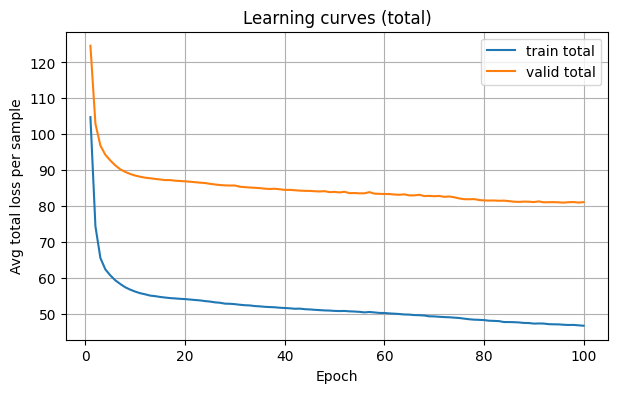

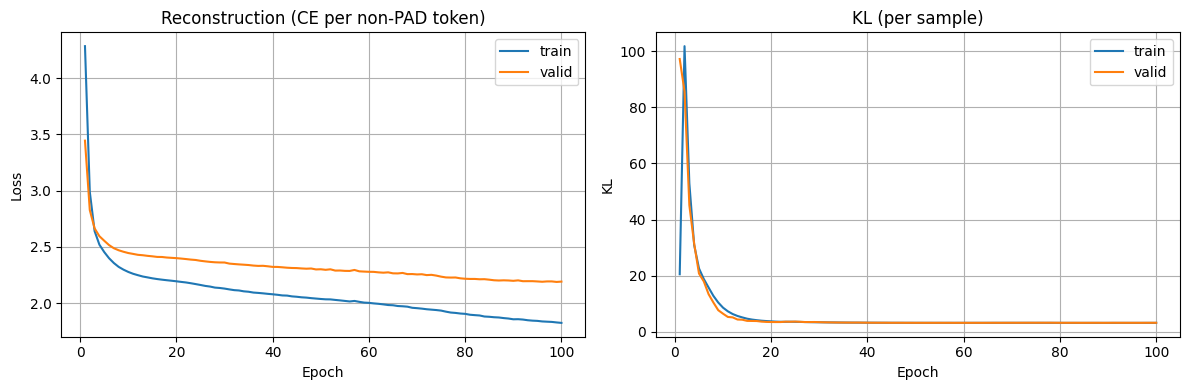

In [82]:
epochs = 100
anneal_epochs = 150  # longer linear KL warm-up to reduce posterior collapse
free_bits_nats = 0.1  # KL floor per latent dim (nats); try 0.05–0.5

def kl_beta(epoch: int) -> float:
    if anneal_epochs <= 1:
        return 1.0
    return float(min(1.0, epoch / anneal_epochs))

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = MoleculeVAE(vocab_size=vocab_size, seq_len=seq_len).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

def train_one_epoch(epoch):
    model.train()
    beta = kl_beta(epoch)

    total = 0.0
    total_recon = 0.0
    total_kl = 0.0
    total_tokens = 0

    for batch_idx, batch in enumerate(train_loader):
        x = batch[0].to(device)  # (B, seq_len, vocab)

        optimizer.zero_grad()
        logits, mean, logvar = model(x)  # (B, seq_len, vocab)

        if batch_idx == 0:
            inp = x[0].detach().cpu().numpy()      # (seq_len, vocab)
            out = logits[0].detach().cpu().numpy() # (seq_len, vocab)
            print("Input:")
            print(decode_one_hot(inp.T, all_chars, pad_char=PAD))
            print("Output:")
            print(decode_one_hot(out.T, all_chars, pad_char=PAD))

        loss, recon_sum, kl_sum, n_nonpad = vae_loss(
            logits,
            x,
            mean,
            logvar,
            pad_idx=PAD_IDX,
            beta=beta,
            free_bits_nats=free_bits_nats,
        )

        loss.backward()
        optimizer.step()

        total += loss.item()
        total_recon += recon_sum.item()
        total_kl += kl_sum.item()
        total_tokens += int(n_nonpad.item())

        if batch_idx % 100 == 0:
            seen = batch_idx * x.size(0)
            n = len(train_loader.dataset)
            pct = 100.0 * batch_idx / len(train_loader)
            recon_per_tok = total_recon / max(1, total_tokens)
            kl_per_sample = total_kl / n
            print(
                f"Train Epoch: {epoch} [{seen}/{n} ({pct:.0f}%)]\t"
                f"beta={beta:.2f}  recon/tok={recon_per_tok:.4f}  kl/sample={kl_per_sample:.4f}"
            )

    # epoch-level metrics
    n = len(train_loader.dataset)
    recon_per_tok = total_recon / max(1, total_tokens)
    kl_per_sample = total_kl / n
    total_per_sample = total / n
    return total_per_sample, recon_per_tok, kl_per_sample, beta

def eval_one_epoch(loader, *, epoch: int):
    model.eval()
    beta = kl_beta(epoch)

    total = 0.0
    total_recon = 0.0
    total_kl = 0.0
    total_tokens = 0

    with torch.no_grad():
        for batch in loader:
            x = batch[0].to(device)
            logits, mean, logvar = model(x)
            loss, recon_sum, kl_sum, n_nonpad = vae_loss(
                logits,
                x,
                mean,
                logvar,
                pad_idx=PAD_IDX,
                beta=beta,
                free_bits_nats=free_bits_nats,
            )
            total += loss.item()
            total_recon += recon_sum.item()
            total_kl += kl_sum.item()
            total_tokens += int(n_nonpad.item())

    n = len(loader.dataset)
    recon_per_tok = total_recon / max(1, total_tokens)
    kl_per_sample = total_kl / n
    total_per_sample = total / n
    return total_per_sample, recon_per_tok, kl_per_sample

train_total = []
valid_total = []
train_recon = []
valid_recon = []
train_kl = []
valid_kl = []
betas = []

for epoch in range(1, epochs + 1):
    tr_total, tr_recon, tr_kl, beta = train_one_epoch(epoch)
    va_total, va_recon, va_kl = eval_one_epoch(valid_loader, epoch=epoch)

    train_total.append(tr_total)
    valid_total.append(va_total)
    train_recon.append(tr_recon)
    valid_recon.append(va_recon)
    train_kl.append(tr_kl)
    valid_kl.append(va_kl)
    betas.append(beta)

    print(
        f"Epoch {epoch}: beta={beta:.2f}  "
        f"train_total={tr_total:.4f} val_total={va_total:.4f}  "
        f"train_recon/tok={tr_recon:.4f} val_recon/tok={va_recon:.4f}  "
        f"train_kl/sample={tr_kl:.4f} val_kl/sample={va_kl:.4f}"
    )

# Total loss curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, epochs + 1), train_total, label="train total")
plt.plot(range(1, epochs + 1), valid_total, label="valid total")
plt.xlabel("Epoch")
plt.ylabel("Avg total loss per sample")
plt.title("Learning curves (total)")
plt.grid(True)
plt.legend()
plt.show()

# Recon + KL curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(range(1, epochs + 1), train_recon, label="train")
axes[0].plot(range(1, epochs + 1), valid_recon, label="valid")
axes[0].set_title("Reconstruction (CE per non-PAD token)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(range(1, epochs + 1), train_kl, label="train")
axes[1].plot(range(1, epochs + 1), valid_kl, label="valid")
axes[1].set_title("KL (per sample)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("KL")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()